# Community Detection

### Import libraries

In [1]:
import math
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
import time
import dimod
from networkx.algorithms.community.quality import modularity as nx_modularity
from dwave.system import LeapHybridSampler
from dwave.system import DWaveSampler, EmbeddingComposite
from dwave.system import FixedEmbeddingComposite
from dwave.system import LeapHybridDQMSampler
from dwave.samplers import SimulatedAnnealingSampler
from dwave.embedding import embed_bqm
from dwave.embedding.chain_strength import uniform_torque_compensation
from minorminer import find_embedding
from dimod import ExactSolver

# To extract, save, and reuse embedding
import json
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

### Load data

In [2]:
# Load preprocessed networks
networks = []
for i in range(5):
    G = nx.read_graphml(f'neuronal_graphs/plane{i+2}.graphml')
    G.remove_nodes_from(list(nx.isolates(G)))
    networks.append(G)
    print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph loaded: 77 nodes, 96 edges
Graph loaded: 119 nodes, 164 edges
Graph loaded: 131 nodes, 182 edges
Graph loaded: 140 nodes, 202 edges
Graph loaded: 164 nodes, 234 edges


# 1 Graph preprocessing

### 1.1 Conversion to adjacency matrix

In [3]:
graphs = []
for i, G in enumerate(networks):
    print(f"\nProcessing graph for plane {i+2}:")

    # Convert directed graph to undirected
    G_undirected = G.to_undirected()

    # Remove any remaining self-loops
    G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

    # Create unweighted adjacency matrix
    A = nx.adjacency_matrix(G_undirected, weight=None).toarray()
    N = G_undirected.number_of_nodes()
    M = G_undirected.number_of_edges()  # Total number of edges

    graphs.append({'G_undirected': G_undirected, 'A': A, 'N': N, 'M': M})

    print(f"\nUndirected graph: {N} nodes, {M} edges")
    print(f"Adjacency matrix shape: {A.shape}")
    print(f"Sparsity: {(A == 0).sum() / A.size * 100:.2f}% zeros")
    print(f"\nDegree statistics:")
    degrees = [G_undirected.degree(n) for n in G_undirected.nodes()]
    print(f"  Min: {min(degrees)}, Max: {max(degrees)}, Mean: {np.mean(degrees):.2f}")


Processing graph for plane 2:

Undirected graph: 77 nodes, 48 edges
Adjacency matrix shape: (77, 77)
Sparsity: 98.38% zeros

Degree statistics:
  Min: 1, Max: 3, Mean: 1.25

Processing graph for plane 3:

Undirected graph: 119 nodes, 82 edges
Adjacency matrix shape: (119, 119)
Sparsity: 98.84% zeros

Degree statistics:
  Min: 1, Max: 3, Mean: 1.38

Processing graph for plane 4:

Undirected graph: 131 nodes, 91 edges
Adjacency matrix shape: (131, 131)
Sparsity: 98.94% zeros

Degree statistics:
  Min: 1, Max: 4, Mean: 1.39

Processing graph for plane 5:

Undirected graph: 140 nodes, 101 edges
Adjacency matrix shape: (140, 140)
Sparsity: 98.97% zeros

Degree statistics:
  Min: 1, Max: 3, Mean: 1.44

Processing graph for plane 6:

Undirected graph: 164 nodes, 117 edges
Adjacency matrix shape: (164, 164)
Sparsity: 99.13% zeros

Degree statistics:
  Min: 1, Max: 4, Mean: 1.43


# 2 Classical community detection

In [4]:
def communities_to_partition(communities):
    """
    Convert a list of community sets to a partition array.
    Returns: array where partition[i] = community_id for node i
    """
    node_list = list(G_undirected.nodes())  # Use the current graph's node order
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    partition = np.zeros(len(node_list), dtype=int)
    for community_id, community_set in enumerate(communities):
        for node in community_set:
            partition[node_to_idx[node]] = community_id
    return partition

def compute_modularity(partition, A):
    """
    Compute modularity Q for a given partition.
    Q = (1/2m) * sum_ij (A_ij - k_i*k_j/2m) * delta(c_i, c_j)
    where k_i is the degree of node i, and delta(c_i, c_j) = 1 if nodes i,j in same community
    """
    n = A.shape[0]

    degrees = A.sum(axis=1)
    m = A.sum() / 2.0  # total edges (double counted in adjacency matrix)
    
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    
    Q /= (2.0 * m)
    return Q

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
    return (np.mean(conductances)+(singleton_count/77)+(double_count/(77*2))) if conductances else np.nan

def greedy_refinement(A, partition):
    """
    Refines the partition using a greedy local search.
    Moves each node to the community that gives the highest modularity increase.
    """
    refined_partition = partition.copy()
    N = A.shape[0]
    unique_communities = np.unique(partition)
    improved = True
    
    current_modularity = compute_modularity(refined_partition, A)
    
    print(f"Starting refinement... Initial Modularity: {current_modularity:.6f}")
    
    while improved:
        improved = False
        nodes = np.random.permutation(N)
        
        for i in nodes:
            best_move = refined_partition[i]
            initial_comm = refined_partition[i]
            for target_comm in unique_communities:
                if target_comm == initial_comm:
                    continue
                refined_partition[i] = target_comm
                new_modularity = compute_modularity(refined_partition, A)
                if new_modularity > current_modularity:
                    current_modularity = new_modularity
                    best_move = target_comm
                    improved = True
            refined_partition[i] = best_move
            
    print(f"Refinement complete. Optimized Modularity: {current_modularity:.6f}")
    return refined_partition


### 2.1 Louvain

Tuning resolution parameter for Louvain

Max Modularity: 0.481262
Number of Communities: 107
Conductance: 1.255660


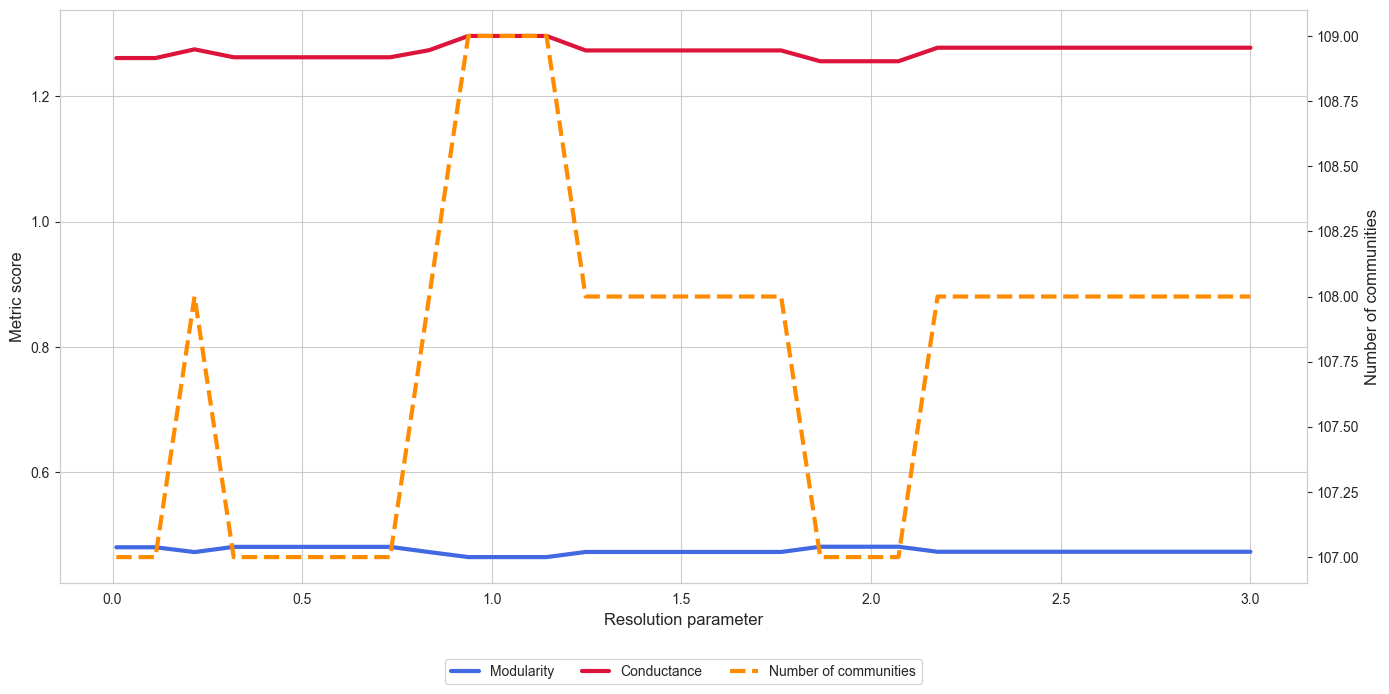

In [5]:
resolution_range = np.linspace(0.01, 3.0, 30)
tuning_results = []
for res in resolution_range:
    start_time = time.time()
    # run Louvain with specified resolution
    communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42, resolution=res))
    runtime = time.time() - start_time
    
    # calculate/post process
    partition_louvain = communities_to_partition(communities_louvain)
    modularity_louvain = compute_modularity(partition_louvain, A)
    conductance_louvain = compute_conductance(partition_louvain, A)
    
    tuning_results.append({
        'resolution': res,
        'num_communities': len(communities_louvain),
        'modularity': modularity_louvain,
        'conductance': conductance_louvain,
        'runtime': runtime
    })

df_tuning = pd.DataFrame(tuning_results)

best_mod_row = df_tuning.loc[df_tuning['modularity'].idxmax()]

print(f"Max Modularity: {best_mod_row['modularity']:.6f}")
print(f"Number of Communities: {int(best_mod_row['num_communities'])}")
print(f"Conductance: {best_mod_row['conductance']:.6f}")

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(data=df_tuning, x='resolution', y='modularity', ax=ax1, label='Modularity', color='royalblue',linewidth=3)
sns.lineplot(data=df_tuning, x='resolution', y='conductance', ax=ax1, label='Conductance', color='crimson', linewidth=3)
ax1.set_ylabel('Metric score', fontsize=12)
ax1.set_xlabel('Resolution parameter', fontsize=12)

ax2 = ax1.twinx()
sns.lineplot(data=df_tuning, x='resolution', y='num_communities', ax=ax2, label='Number of communities', color='darkorange', linestyle='--', linewidth=3)
ax2.set_ylabel('Number of communities', fontsize=12)
ax2.grid(False) 

# sync legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)

plt.tight_layout()
plt.show()

In [6]:
louvain_results = []
for i in range(5):
    print(f"\nProcessing graph for plane {i+2}:")
    G_undirected = graphs[i]['G_undirected']
    A = graphs[i]['A']

    start_time = time.time()
    # maximized modularity & lowest conductance at resolution = 0.5
    communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42, resolution=0.5))
    louvain_runtime = time.time() - start_time

    partition_louvain = communities_to_partition(communities_louvain)
    partition_louvain_optimized = greedy_refinement(A, partition_louvain)
    modularity_louvain = compute_modularity(partition_louvain_optimized, A)
    conductance_louvain = compute_conductance(partition_louvain_optimized, A)

    community_sizes = sorted([len(c) for c in communities_louvain], reverse=True)

    louvain_results.append({
        'runtime': louvain_runtime,
        'num_communities': len(communities_louvain),
        'modularity': modularity_louvain,
        'conductance': conductance_louvain,
        'community_sizes': community_sizes
    })

    print(f"Runtime: {louvain_runtime:.4f}s")
    print(f"Number of communities: {len(communities_louvain)}")
    print(f"Modularity: {modularity_louvain:.6f}")
    print(f"Conductance: {conductance_louvain:.6f}")
    print(f"Community sizes: {community_sizes}")

df_louvain = pd.DataFrame(louvain_results)


Processing graph for plane 2:
Starting refinement... Initial Modularity: 0.490234
Refinement complete. Optimized Modularity: 0.917535
Runtime: 0.0021s
Number of communities: 52
Modularity: 0.917535
Conductance: 0.159978
Community sizes: [4, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Processing graph for plane 3:
Starting refinement... Initial Modularity: 0.479700
Refinement complete. Optimized Modularity: 0.885782
Runtime: 0.0034s
Number of communities: 78
Modularity: 0.885782
Conductance: 0.260510
Community sizes: [5, 4, 4, 4, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Processing graph for plane 4:
Starting refinement... Initial Modularity: 0.517148
Refinement complete. Optimized Modularity: 0.8549

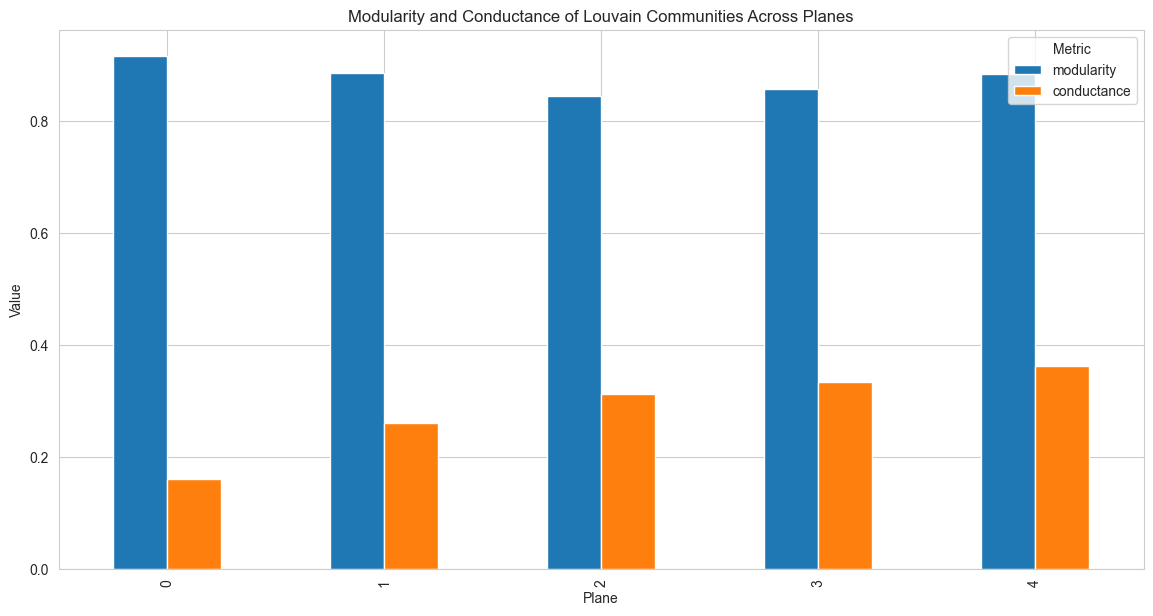

In [16]:
# Modularity and conductance bar plot across planes
plt.figure(figsize=(14, 7))
df_louvain.plot(y=['modularity', 'conductance'], kind='bar', ax=plt.gca())
plt.title('Modularity and Conductance of Louvain Communities Across Planes')
plt.ylabel('Value')
plt.xlabel('Plane')
plt.legend(title='Metric')
plt.show()

### 2.2 Greedy modularity optimization

In [ ]:
greedy_results = []
for i in range(5):
    print(f"\nProcessing graph for plane {i+2}:")
    G_undirected = graphs[i]['G_undirected']
    A = graphs[i]['A']

    start_time = time.time()
    communities_greedy = list(nx.community.greedy_modularity_communities(G_undirected))
    greedy_runtime = time.time() - start_time

    # No need for optimization because it accomplishes the same (greedy)

    partition_greedy = communities_to_partition(communities_greedy)
    modularity_greedy = compute_modularity(partition_greedy, A)
    conductance_greedy = compute_conductance(partition_greedy, A)

    community_sizes = sorted([len(c) for c in communities_louvain], reverse=True)

    greedy_results.append({
        'runtime': greedy_runtime,
        'num_communities': len(communities_greedy),
        'modularity': modularity_greedy,
        'conductance': conductance_greedy,
        'community_sizes': community_sizes
    })

    print(f"Runtime: {greedy_runtime:.4f}s")
    print(f"Number of communities: {len(communities_greedy)}")
    print(f"Modularity: {modularity_greedy:.6f}")
    print(f"Conductance: {conductance_greedy:.6f}")
    print(f"Community sizes: {community_sizes}")

df_greedy = pd.DataFrame(greedy_results)


Processing graph for plane 2:
Runtime: 0.0049s
Number of communities: 29
Modularity: 0.950521
Conductance: 0.123377
Community sizes: [4, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Processing graph for plane 3:
Runtime: 0.0038s
Number of communities: 38
Modularity: 0.962225
Conductance: 0.123377
Community sizes: [4, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Processing graph for plane 4:
Runtime: 0.0096s
Number of communities: 44
Modularity: 0.

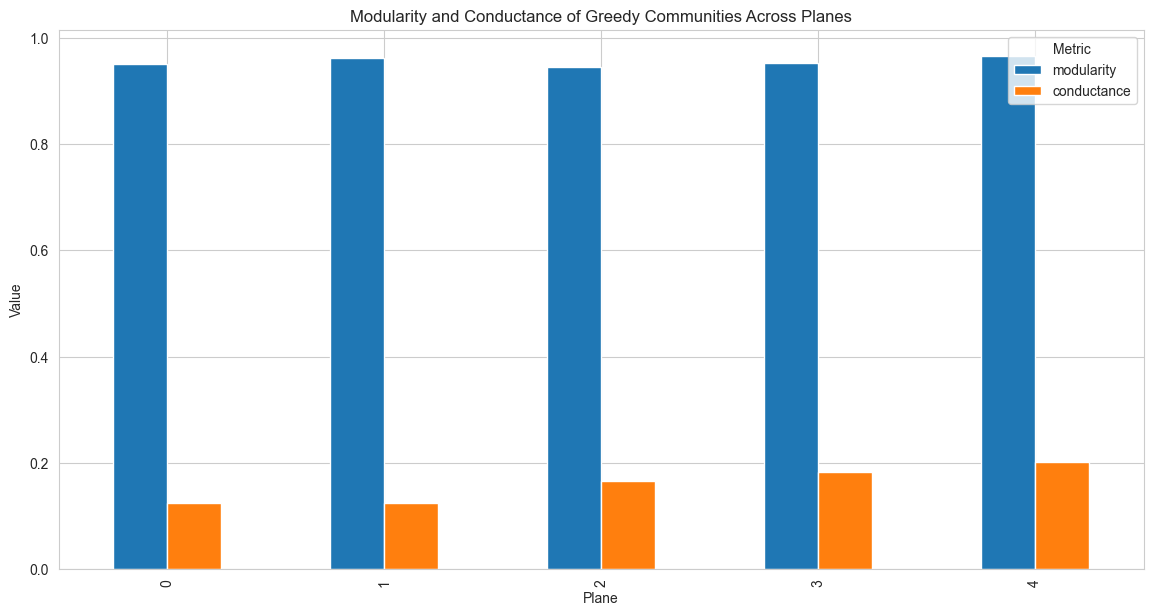

In [18]:
# Modularity and conductance bar plot across planes
plt.figure(figsize=(14, 7))
df_greedy.plot(y=['modularity', 'conductance'], kind='bar', ax=plt.gca())
plt.title('Modularity and Conductance of Greedy Communities Across Planes')
plt.ylabel('Value')
plt.xlabel('Plane')
plt.legend(title='Metric')
plt.show()

### 2.3 Greedy w/ best_n

In [26]:
greedy_bestn_results = []
for i in range(5):
    print(f"\nProcessing graph for plane {i+2}:")
    G_undirected = graphs[i]['G_undirected']
    A = graphs[i]['A']

    start_time = time.time()
    communities_greedy_bestn = list(nx.community.greedy_modularity_communities(G_undirected, best_n=math.sqrt(N)))
    greedy_bestn_runtime = time.time() - start_time

    partition_greedy_bestn = communities_to_partition(communities_greedy_bestn)
    modularity_greedy_bestn = compute_modularity(partition_greedy_bestn, A)
    conductance_greedy_bestn = compute_conductance(partition_greedy_bestn, A)

    community_sizes = sorted([len(c) for c in communities_greedy_bestn], reverse=True)

    greedy_bestn_results.append({
        'runtime': greedy_bestn_runtime,
        'num_communities': len(communities_greedy_bestn),
        'modularity': modularity_greedy_bestn,
        'conductance': conductance_greedy_bestn,
        'community_sizes': community_sizes
    })

    print(f"Runtime: {greedy_bestn_runtime:.4f}s")
    print(f"Number of communities: {len(communities_greedy_bestn)}")
    print(f"Modularity: {modularity_greedy_bestn:.6f}")
    print(f"Conductance: {conductance_greedy_bestn:.6f}")
    print(f"Community sizes: {community_sizes}")

df_greedy_bestn = pd.DataFrame(greedy_bestn_results)


Processing graph for plane 2:
Runtime: 0.0047s
Number of communities: 12
Modularity: 0.401042
Conductance: 0.071429
Community sizes: [55, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Processing graph for plane 3:
Runtime: 0.0074s
Number of communities: 12
Modularity: 0.248662
Conductance: 0.071429
Community sizes: [97, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Processing graph for plane 4:
Runtime: 0.0148s
Number of communities: 12
Modularity: 0.225818
Conductance: 0.071429
Community sizes: [109, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Processing graph for plane 5:
Runtime: 0.0072s
Number of communities: 12
Modularity: 0.204882
Conductance: 0.071429
Community sizes: [118, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Processing graph for plane 6:
Runtime: 0.0048s
Number of communities: 12
Modularity: 0.178391
Conductance: 0.071429
Community sizes: [142, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


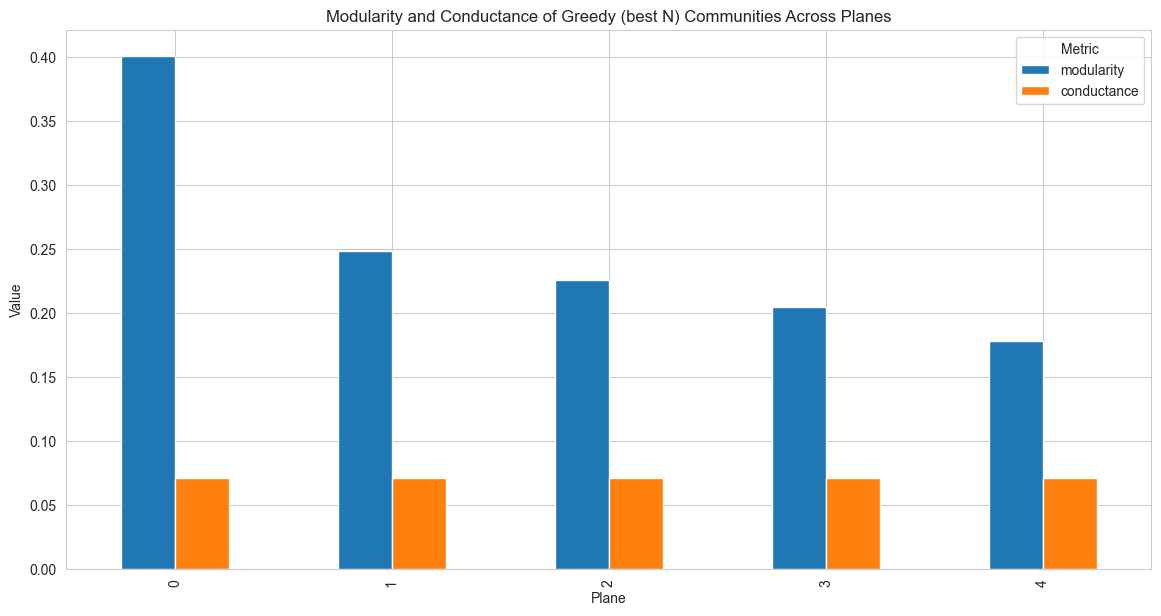

In [21]:
# Modularity and conductance bar plot across planes
plt.figure(figsize=(14, 7))
df_greedy_bestn.plot(y=['modularity', 'conductance'], kind='bar', ax=plt.gca())
plt.title('Modularity and Conductance of Greedy (best N) Communities Across Planes')
plt.ylabel('Value')
plt.xlabel('Plane')
plt.legend(title='Metric')
plt.show()

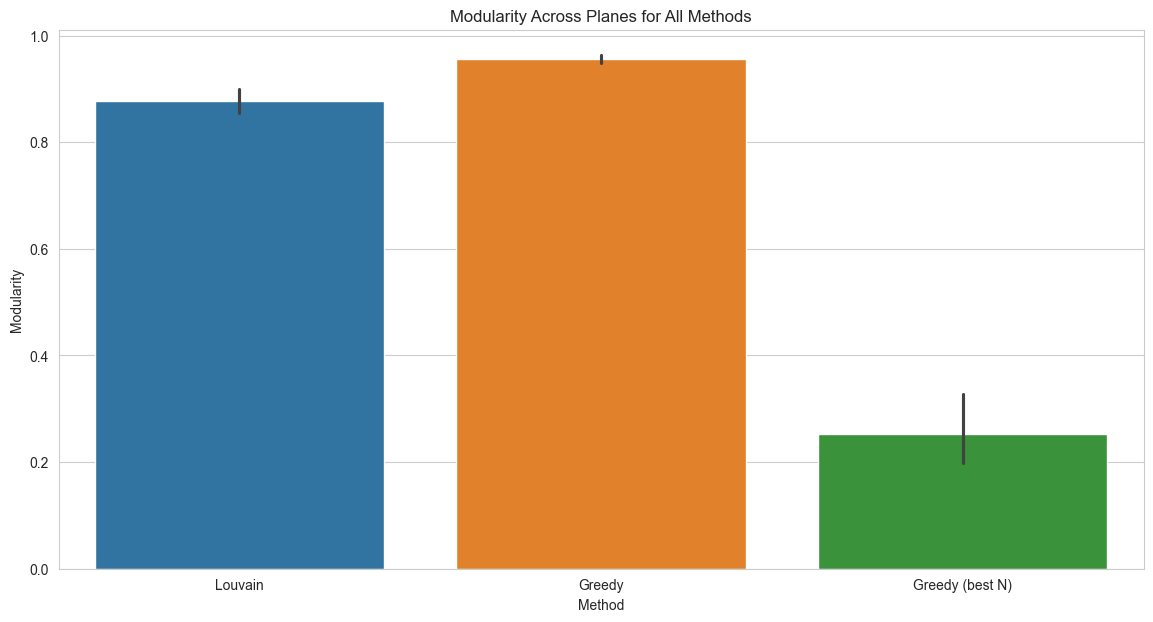

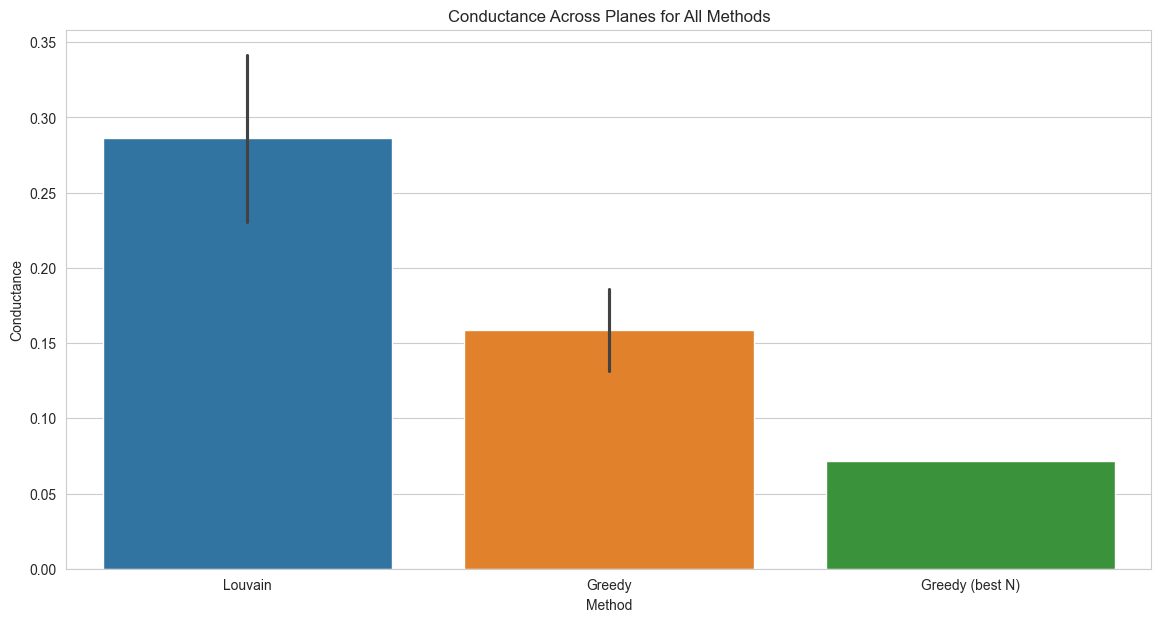

In [23]:
# Modularity across planes for all methods
plt.figure(figsize=(14, 7))
sns.barplot(data=pd.concat([df_louvain.assign(method='Louvain'), df_greedy.assign(method='Greedy'), df_greedy_bestn.assign(method='Greedy (best N)')]), x='method', y='modularity', hue='method')
plt.title('Modularity Across Planes for All Methods')
plt.ylabel('Modularity')
plt.xlabel('Method')
plt.show()

# Conductance across planes for all methods
plt.figure(figsize=(14, 7))
sns.barplot(data=pd.concat([df_louvain.assign(method='Louvain'), df_greedy.assign(method='Greedy'), df_greedy_bestn.assign(method='Greedy (best N)')]), x='method', y='conductance', hue='method')
plt.title('Conductance Across Planes for All Methods')
plt.ylabel('Conductance')
plt.xlabel('Method')
plt.show()

# 3 QUBO with Modularity

### 3.0 Build QUBO matrix

In [27]:
def build_modularity_qubo(A, num_communities=None, lambda_penalty=None, verbose=False):
    """
    Build QUBO matrix for modularity maximization via binary community assignment.
    Variables: x_{i,c} for i in nodes, c in communities
    Constraint: Each node assigned to exactly one community (handled via penalty)
    
    One-hot encoding:
    - num_binary_vars = N * num_communities
    - x[i*num_communities + c] = 1 if node i in community c
    
    QUBO objective: minimize -Q + lambda * penalty
    
    Parameters:
    -----------
    A : ndarray
        Adjacency matrix
    num_communities : int, optional
        Number of communities (default: sqrt(N))
    lambda_penalty : float, optional
        Penalty weight for one-hot constraint.
        If None, automatically set to 10x the max modularity contribution.
    verbose : bool
        Print diagnostics
    """

    if num_communities is None:
        num_communities = max(2, int(np.sqrt(N)))

    n_vars = N * num_communities 
    Q = {}

    degrees = A.sum(axis=1)
    m = A.sum() / 2  # Total edges

    # Modularity term: Q = (1/2m) * sum_{c} sum_{i,j} B_{ij} x_{i,c} x_{j,c}
    # For minimization, use -Q in QUBO objective
    max_B = 0  # Track max modularity contribution for scaling
    
    for c in range(num_communities):
        for i in range(N):
            for j in range(i, N):
                var_i = i * num_communities + c
                var_j = j * num_communities + c
                B_ij = A[i, j] - (degrees[i] * degrees[j]) / (2 * m)
                coeff = -B_ij / (2 * m)
                max_B = max(max_B, abs(coeff))

                if i == j:  # diagonal
                    if var_i not in Q:
                        Q[var_i] = 0.0
                    Q[var_i] += coeff
                else:  # off-diagonal
                    key = (var_i, var_j) if var_i < var_j else (var_j, var_i)
                    if key not in Q:
                        Q[key] = 0.0
                    Q[key] += coeff

    if lambda_penalty is None:
        lambda_penalty = max(10.0 * max_B, 5.0)  # At least 5.0
    
    if verbose:
        print(f"Modularity scale (max |coeff|): {max_B:.6f}")
        print(f"Penalty weight (lambda): {lambda_penalty:.6f}")

    # Constraint penalty: each node in exactly one community
    # Penalty: lambda * (sum_c x_{i,c} - 1)^2
    # Expansion:
    #   (sum_c x_{i,c} - 1)^2 = sum_c x_{i,c}^2 + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1
    #   = sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1   [since x^2=x for binary]
    #   = -sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} + 1
    
    # Linear coefficient: -lambda per variable
    # Quadratic coefficient: +2*lambda per pair

    const_term = N * lambda_penalty
    
    for i in range(N):
        # Linear terms: -lambda * x_{i,c}
        for c in range(num_communities):
            var_i = i * num_communities + c
            if var_i not in Q:
                Q[var_i] = 0.0
            Q[var_i] += -lambda_penalty

        # Quadratic terms: +2*lambda * x_{i,c1}*x_{i,c2}
        for c1 in range(num_communities):
            for c2 in range(c1 + 1, num_communities):
                var_1 = i * num_communities + c1
                var_2 = i * num_communities + c2
                key = (var_1, var_2) if var_1 < var_2 else (var_2, var_1)
                if key not in Q:
                    Q[key] = 0.0
                Q[key] += 2.0 * lambda_penalty

    Q['__const__'] = const_term
    
    if verbose:
        print(f"Constant term (N*lambda): {const_term:.2f}")
        print(f"Total QUBO terms: {len(Q)-1} + 1 const")  # -1 for const term itself

    return Q, num_communities

In [36]:
# Estimate reasonable number of communities
num_communities_target = max(2, int(np.sqrt(N)))
print(f"Target number of communities: {num_communities_target}")
print(f"Total QUBO variables: {N * num_communities_target}")

# Build QUBO
print(f"\nBuilding QUBO matrix...")
Q_dict, k_communities = build_modularity_qubo(A, num_communities_target, verbose=True)
print(f"QUBO built with {len(Q_dict)-1} terms")
print(f"Constant term: {Q_dict.get('__const__', 0):.2f}")

Target number of communities: 8
Total QUBO variables: 616

Building QUBO matrix...
Modularity scale (max |coeff|): 0.010308
Penalty weight (lambda): 5.000000
Constant term (N*lambda): 385.00
Total QUBO terms: 26180 + 1 const
QUBO built with 26180 terms
Constant term: 385.00


In [37]:
# Convert QUBO to BQM (Binary Quadratic Model) for D-Wave
Q_dict_clean = {}
const_offset = 0

for k, v in Q_dict.items():
    if k == '__const__':
        # Extract constant term for later addition
        const_offset = float(v)
    elif isinstance(k, tuple):
        Q_dict_clean[k] = float(v)
    else:
        node_idx = int(k)
        Q_dict_clean[(node_idx, node_idx)] = float(v)

# Create BQM and add the constant offset
bqm = dimod.BinaryQuadraticModel.from_qubo(Q_dict_clean)

# Add constant term to the BQM's offset
bqm.offset += const_offset

print(f"BQM created: {bqm.num_variables} variables, {len(bqm.quadratic)} interactions")
print(f"BQM offset (constant term): {bqm.offset:.2f}")

BQM created: 616 variables, 25564 interactions
BQM offset (constant term): 385.00


### 3.1 Classical solvers

Simulated annealing

In [39]:
start_time = time.time()
sa_sampler = SimulatedAnnealingSampler()
sampleset_sa = sa_sampler.sample(bqm, num_reads=100, seed=42)
sa_runtime = time.time() - start_time

best_sample_sa = sampleset_sa.first.sample
best_energy_sa = sampleset_sa.first.energy

print(f"Runtime: {sa_runtime:.4f}s")
print(f"Best energy: {best_energy_sa:.6f}")
print(f"Number of reads: 100")
print(f"Top 5 solutions:")

# Convert generator into list
top5 = list(sampleset_sa.data(['sample', 'energy', 'num_occurrences'], sorted_by='energy'))[:5]
for i, (sample, energy, num_occurrences) in enumerate(top5):
    print(f"  {i+1}. Energy: {energy:.6f}, Occurrences: {num_occurrences}")

Runtime: 1.1424s
Best energy: -0.038737
Number of reads: 100
Top 5 solutions:
  1. Energy: -0.038737, Occurrences: 1
  2. Energy: -0.027452, Occurrences: 1
  3. Energy: -0.021376, Occurrences: 1
  4. Energy: -0.020942, Occurrences: 1
  5. Energy: -0.018772, Occurrences: 1


In [15]:
def extract_communities_from_sample(sample, N, k_communities):
    """
    Extract community assignments from QUBO sample.
    For node i, find c where x_{i,c} = 1
    """
    partition = np.zeros(N, dtype=int)
    
    for i in range(N):
        # Find which community this node is assigned to
        for c in range(k_communities):
            var_idx = i * k_communities + c
            if var_idx in sample and sample[var_idx] == 1:
                partition[i] = c
                break
        else:
            # If no community assigned (constraint violation), assign to community 0
            partition[i] = 0
    
    return partition
count = 1

for sample, energy, num_occurrences in top5:
    partition_sa = extract_communities_from_sample(sample, N, k_communities)
    modularity_sa = compute_modularity(partition_sa, A)
    conductance_sa = compute_conductance(partition_sa, A)
    num_communities_found_sa = len(np.unique(partition_sa))
    
    print(f"\nPartition from sample with energy {energy:.6f}:")
    print(f"\nSample {count}:")
    print(f"  Number of communities found: {num_communities_found_sa}")
    print(f"  Modularity: {modularity_sa:.6f}")
    print(f"  Conductance: {conductance_sa:.6f}")
    print(f"  Community sizes: {sorted(np.bincount(partition_sa), reverse=True)}")
    count += 1


Partition from sample with energy -0.038737:

Sample 1:
  Number of communities found: 8
  Modularity: 0.092665
  Conductance: 0.786169
  Community sizes: [np.int64(14), np.int64(13), np.int64(12), np.int64(9), np.int64(9), np.int64(7), np.int64(7), np.int64(6)]

Partition from sample with energy -0.027452:

Sample 2:
  Number of communities found: 8
  Modularity: 0.070095
  Conductance: 0.823611
  Community sizes: [np.int64(14), np.int64(13), np.int64(11), np.int64(9), np.int64(8), np.int64(8), np.int64(7), np.int64(7)]

Partition from sample with energy -0.021376:

Sample 3:
  Number of communities found: 8
  Modularity: 0.057943
  Conductance: 0.815350
  Community sizes: [np.int64(13), np.int64(12), np.int64(11), np.int64(11), np.int64(8), np.int64(8), np.int64(7), np.int64(7)]

Partition from sample with energy -0.020942:

Sample 4:
  Number of communities found: 8
  Modularity: 0.057075
  Conductance: 0.807561
  Community sizes: [np.int64(14), np.int64(13), np.int64(11), np.int64

### 3.2 Quantum/hybrid solvers

3.2a D-Wave LeapHybrid (quantum+classical, requires Leap account)

In [18]:
start_time = time.time()
sampler = LeapHybridSampler()
sampleset_hybrid = sampler.sample(bqm, time_limit=10)

# target_edgelist = sampler.edgelist
# find_embedding(bqm.quadratic, target_edgelist)

# sampleset_hybrid = hybrid_sampler.sample(bqm, time_limit=1)
hybrid_runtime = time.time() - start_time

best_sample_hybrid = sampleset_hybrid.first.sample
best_energy_hybrid = sampleset_hybrid.first.energy
# use_hybrid = True

In [19]:
print(sampler.solver.name)

hybrid_binary_quadratic_model_version2p


In [68]:
# Refine with greedy optimization
partition_hybrid_raw = extract_communities_from_sample(best_sample_hybrid, N, k_communities)
print("Applying greedy refinement to hybrid solution...")
partition_hybrid_optimized = greedy_refinement(A, partition_hybrid_raw)
partition_hybrid = extract_communities_from_sample(best_sample_hybrid, N, k_communities)

num_communities_found_hybrid = len(np.unique(partition_hybrid))
conductance_hybrid = compute_conductance(partition_hybrid, A)
mod_raw = compute_modularity(partition_hybrid_raw, A)
mod_opt = compute_modularity(partition_hybrid_optimized, A)

print(f"Runtime: {hybrid_runtime:.4f}s")
print(f"Best energy: {best_energy_hybrid:.6f}")
print(f"Number of communities found: {num_communities_found_hybrid}")
print(f"Original hybrid modularity: {mod_raw:.6f}")
print(f"Optimized hybrid modularity: {mod_opt:.6f}")
print(f"Conductance: {conductance_hybrid:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_hybrid), reverse=True)}")

Applying greedy refinement to hybrid solution...
Starting refinement... Initial Modularity: 0.241970
Refinement complete. Optimized Modularity: 0.803168
Runtime: 2.8203s
Best energy: -0.113390
Number of communities found: 8
Original hybrid modularity: 0.241970
Optimized hybrid modularity: 0.803168
Conductance: 0.662784
Community sizes: [np.int64(13), np.int64(12), np.int64(11), np.int64(10), np.int64(9), np.int64(8), np.int64(8), np.int64(6)]


3.2bi D-Wave QPU sampler (Advantage 1)

In [ ]:
Dsampler = DWaveSampler(solver={'name': 'Advantage_system4.1'})
print("Connected to sampler", Dsampler.solver.name)

qpu_sampler = EmbeddingComposite(Dsampler)
total_actual_qpu_micros = 0

# parameters
variables = list(bqm.variables)
chunk_size = 100
current_sample = {}
for i in range(N):
    # Randomly assign each node to ONE community (one-hot)
    comm = np.random.randint(0, k_communities)
    for c in range(k_communities):
        current_sample[i * k_communities + c] = 1 if c == comm else 0
total_qpu_time = 0

print(f"Starting QPU decomposition loop on: {Dsampler.properties['chip_id']}")

for i in range(0, len(variables), chunk_size):
    # Select a subset of variables to optimize
    subset = variables[i : i + chunk_size]

    fixed_vars = {v: current_sample[v] for v in variables if v not in subset}
    sub_bqm = bqm.copy()
    sub_bqm.fix_variables(fixed_vars)
    
    loop_start = time.time()
    
    try:
        sampleset = qpu_sampler.sample(sub_bqm, num_reads=1000, chain_strength=2.0, annealing_time=100, label=f'Part {i}')
        qpu_micros = sampleset.info['timing']['qpu_access_time']
        total_actual_qpu_micros += qpu_micros
        best_sub_sample = sampleset.first.sample
        current_sample.update(best_sub_sample)
        current_sample = {int(k): int(v) for k, v in current_sample.items()}
        
    except ValueError as e:
        print(f"Sub-problem {i} failed: {e}")
        continue
        
    loop_end = time.time()
    
    elapsed = loop_end - loop_start
    total_qpu_time += elapsed
    
    print(f"Chunk {i//chunk_size + 1}: processed in {elapsed:.4f}s")

print(f"\nTotal Loop Runtime: {total_qpu_time:.4f}s")
total_qpu_seconds = total_actual_qpu_micros / 1000000
print(f"Total Pure QPU Access Time: {total_qpu_seconds:.6f}s")
print(f"Total QPU Seconds Per Read: {total_qpu_seconds / 1000:.6f}s")
best_sample_qpu = current_sample
partition_qpu = np.zeros(N, dtype=int)

Connected to sampler Advantage_system4.1
Starting QPU decomposition loop on: Advantage_system4.1
Chunk 1: processed in 126.2641s
Chunk 2: processed in 58.7580s
Chunk 3: processed in 68.2038s
Chunk 4: processed in 111.7588s
Chunk 5: processed in 50.1021s
Chunk 6: processed in 82.5292s
Chunk 7: processed in 1.3778s

Total Loop Runtime: 498.9940s
Total Pure QPU Access Time: 1.976035s
Total QPU Seconds Per Read: 0.001976s


In [ ]:
# Postprocessing
partition_qpu = np.zeros(N, dtype=int)
unassigned_nodes = 0

for i in range(N):
    node_vars = [current_sample.get(i * k_communities + c, 0) for c in range(k_communities)]
    
    if sum(node_vars) == 1:
        partition_qpu[i] = np.argmax(node_vars)
    elif sum(node_vars) > 1:
        partition_qpu[i] = np.argmax(node_vars)
    else:
        unassigned_nodes += 1
        partition_qpu[i] = 0 # This defaults to Community 0
print(f"Nodes failed by QPU: {unassigned_nodes} out of {N}")

print("Applying advanced refinement to QPU solution...")
partition_qpu_optimized = advanced_refinement(A, partition_qpu)

modularity_qpu = compute_modularity(partition_qpu_optimized, A)
conductance_qpu = compute_conductance(partition_qpu_optimized, A)
print(f"Advanced Optimized QPU Modularity: {modularity_qpu:.6f}")
print(f"Advanced Optimized QPU Conductance: {conductance_qpu:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_qpu_optimized), reverse=True)}")

Nodes failed by QPU: 0 out of 77
Applying advanced refinement to QPU solution...
Advanced Optimized QPU Modularity: 0.825521
Advanced Optimized QPU Conductance: 0.012987
Community sizes: [np.int64(21), np.int64(14), np.int64(12), np.int64(10), np.int64(10), np.int64(6), np.int64(2), np.int64(2)]


3.2bii D-Wave QPU Sampler (Advantage 2)

In [44]:
Dsampler = DWaveSampler(solver={'name': 'Advantage2_system1'})
print("Connected to sampler", Dsampler.solver.name)

qpu_sampler = EmbeddingComposite(Dsampler)
total_actual_qpu_micros = 0

# parameters
variables = list(bqm.variables)
chunk_size = 100
current_sample = {}
for i in range(N):
    # Randomly assign each node to ONE community (one-hot)
    comm = np.random.randint(0, k_communities)
    for c in range(k_communities):
        current_sample[i * k_communities + c] = 1 if c == comm else 0
total_qpu_time = 0

print(f"Starting QPU decomposition loop on: {Dsampler.properties['chip_id']}")

for i in range(0, len(variables), chunk_size):
    # Select a subset of variables to optimize
    subset = variables[i : i + chunk_size]

    fixed_vars = {v: current_sample[v] for v in variables if v not in subset}
    sub_bqm = bqm.copy()
    sub_bqm.fix_variables(fixed_vars)
    
    loop_start = time.time()
    
    try:
        sampleset = qpu_sampler.sample(sub_bqm, num_reads=1000, chain_strength=2.0, annealing_time=100, label=f'Part {i}')
        qpu_micros = sampleset.info['timing']['qpu_access_time']
        total_actual_qpu_micros += qpu_micros
        best_sub_sample = sampleset.first.sample
        current_sample.update(best_sub_sample)
        current_sample = {int(k): int(v) for k, v in current_sample.items()}
        
    except ValueError as e:
        print(f"Sub-problem {i} failed: {e}")
        continue
        
    loop_end = time.time()
    
    elapsed = loop_end - loop_start
    total_qpu_time += elapsed
    
    print(f"Chunk {i//chunk_size + 1}: processed in {elapsed:.4f}s")

print(f"\nTotal Loop Runtime: {total_qpu_time:.4f}s")
total_qpu_seconds = total_actual_qpu_micros / 1000000
print(f"Total Pure QPU Access Time: {total_qpu_seconds:.6f}s")
print(f"Total QPU Seconds Per Read: {total_qpu_seconds / 1000:.6f}s")
best_sample_qpu = current_sample
partition_qpu = np.zeros(N, dtype=int)

Connected to sampler Advantage2_system1
Starting QPU decomposition loop on: Advantage2_system1
Chunk 1: processed in 511.4643s
Chunk 2: processed in 132.1562s
Chunk 3: processed in 205.0552s
Chunk 4: processed in 229.8224s
Chunk 5: processed in 131.9067s
Chunk 6: processed in 51.2304s
Chunk 7: processed in 1.5713s

Total Loop Runtime: 1263.2065s
Total Pure QPU Access Time: 1.899047s
Total QPU Seconds Per Read: 0.001899s


In [73]:
# Postprocessing
partition_qpu = np.zeros(N, dtype=int)
unassigned_nodes = 0

for i in range(N):
    node_vars = [current_sample.get(i * k_communities + c, 0) for c in range(k_communities)]
    
    if sum(node_vars) == 1:
        partition_qpu[i] = np.argmax(node_vars)
    elif sum(node_vars) > 1:
        partition_qpu[i] = np.argmax(node_vars)
    else:
        unassigned_nodes += 1
        partition_qpu[i] = 0 # This defaults to Community 0
print(f"Nodes failed by QPU: {unassigned_nodes} out of {N}")

print("Applying advanced refinement to QPU solution...")
partition_qpu_optimized = advanced_refinement(A, partition_qpu)

modularity_qpu = compute_modularity(partition_qpu_optimized, A)
conductance_qpu = compute_conductance(partition_qpu_optimized, A)
print(f"Advanced Optimized QPU Modularity: {modularity_qpu:.6f}")
print(f"Advanced Optimized QPU Conductance: {conductance_qpu:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_qpu_optimized), reverse=True)}")

Nodes failed by QPU: 0 out of 77
Applying advanced refinement to QPU solution...
Advanced Optimized QPU Modularity: 0.825521
Advanced Optimized QPU Conductance: 0.006494
Community sizes: [np.int64(20), np.int64(16), np.int64(11), np.int64(11), np.int64(10), np.int64(4), np.int64(3), np.int64(2)]


### Save partitions for further analysis

In [ ]:
saved_partitions = [partition_louvain, partition_greedy, partition_greedy_bestn, partition_hybrid_optimized, partition_qpu_optimized]
partition_names = ['louvain', 'greedy', 'greedy_bestn', 'hybrid_optimized', 'qpu_optimized']

for i in range(len(saved_partitions)):
    with open(f'partitions/partition_{partition_names[i]}.json', 'w') as f:
        json.dump(saved_partitions[i].tolist(), f)

# *** Incomplete Implementation ***

3.2c Hybrid

In [ ]:
# Variant A: Classical vs Quantum racing
workflow_v1 = hybrid.Loop(
    hybrid.RacingBranches(
        hybrid.InterruptableTabuSampler(),
        hybrid.QPUSubproblemAutoEmbeddingSampler()
    ) | hybrid.ArgMin(),
    convergence=3)

# Variant B: Multiple classical heuristics racing
workflow_v2 = hybrid.Loop(
    hybrid.RacingBranches(
        hybrid.InterruptableTabuSampler(),
        hybrid.SteepestDescentSolver(),
        hybrid.RandomSampler()
    ) | hybrid.ArgMin(),
    convergence=3)

# Variant C: Decompose then race
workflow_v3 = hybrid.Loop(
    hybrid.EnergyImpactDecomposer(size=40, rolling=True)
    | hybrid.RacingBranches(
        hybrid.QPUSubproblemAutoEmbeddingSampler(),
        hybrid.GreedyPathMergeSampler()
    ) | hybrid.ArgMin(),
    convergence=3)

In [ ]:
import hybrid
# Set a workflow of tabu search in parallel to submissions to a D-Wave system
workflow = hybrid.Loop(
   hybrid.RacingBranches(
      hybrid.InterruptableTabuSampler(),
      hybrid.EnergyImpactDecomposer(size=30, rolling=True, rolling_history=0.75)
      | hybrid.QPUSubproblemAutoEmbeddingSampler()
      | hybrid.SplatComposer()) | hybrid.ArgMin(), convergence=3)

# Convert to dimod sampler and run workflow
result = hybrid.HybridSampler(workflow).sample(bqm)

In [ ]:
best_sample_hybrid = result.first.sample
best_energy_hybrid = result.first.energy

# Refine with greedy optimization
partition_hybrid_raw = extract_communities_from_sample(result, N, k_communities)
print("Applying greedy refinement to hybrid solution...")
partition_hybrid_optimized = greedy_refinement(A, partition_hybrid_raw)
partition_hybrid = extract_communities_from_sample(result, N, k_communities)

num_communities_found_hybrid = len(np.unique(partition_hybrid))
conductance_hybrid = compute_conductance(partition_hybrid, A)
mod_raw = compute_modularity(partition_hybrid_raw, A)
mod_opt = compute_modularity(partition_hybrid_optimized, A)

print(f"Best energy: {best_energy_hybrid:.6f}")
print(f"Number of communities found: {num_communities_found_hybrid}")
print(f"Original Hybrid Modularity: {mod_raw:.6f}")
print(f"Optimized Hybrid Modularity: {mod_opt:.6f}")
print(f"Conductance: {conductance_hybrid:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_hybrid), reverse=True)}")

Applying greedy refinement to hybrid solution...
Starting refinement... Initial Modularity: -0.000000
Refinement complete. Optimized Modularity: -0.000000
Graph contains 0 single-node communities
Best energy: -700.153106
Number of communities found: 1
Original Hybrid Modularity: -0.000000
Optimized Hybrid Modularity: -0.000000
Conductance: 0.000000
Community sizes: [np.int64(70)]


3.2d Stride

# 4 Discrete Quadratic Model

In [32]:
def build_modularity_dqm(A, num_communities):
    """
    Build DQM (Discrete Quadratic Model) for modularity maximization.

    Variables: x_i for i in nodes, where x_i in {0, 1, ..., num_communities-1}
    x_i = c means node i is in community c

    Objective: minimize -Q, where Q is modularity
    """
    from dimod import DiscreteQuadraticModel
    
    dqm = DiscreteQuadraticModel()
    
    # Add variables: each node has discrete variable with num_communities possible values
    for i in range(N):
        dqm.add_variable(num_communities, label=i)
    
    degrees = A.sum(axis=1)
    m = A.sum() / 2
    
    # Modularity term: Q = (1/2m) * sum_{i<j} B_ij * delta(x_i, x_j)
    # Since DQM minimizes, we use -Q as objective
    for i in range(N):
        for j in range(i+1, N):
            B_ij = A[i, j] - (degrees[i] * degrees[j]) / (2 * m)
            coeff = -B_ij / (2 * m)  # Negative because we minimize -Q
            
            # For each community c, add quadratic term when both nodes are in c
            for c in range(num_communities):
                dqm.set_quadratic(i, j, {(c, c): coeff})
    
    return dqm


In [40]:
# Build DQM
print(f"\nBuilding DQM matrix...")
dqm = build_modularity_dqm(A, num_communities_target)
print(f"DQM built with {dqm.num_variables()} variables")



Building DQM matrix...
DQM built with 77 variables


In [41]:
start_time = time.time()
dqm_sampler = LeapHybridDQMSampler()
sampleset_dqm = dqm_sampler.sample_dqm(dqm, time_limit=10)
dqm_runtime = time.time() - start_time

best_sample_dqm = sampleset_dqm.first.sample
best_energy_dqm = sampleset_dqm.first.energy

print(f"DQM Runtime: {dqm_runtime:.4f}s")
print(f"Best energy: {best_energy_dqm:.6f}")


DQM Runtime: 3.0467s
Best energy: -0.445095


In [44]:
# Extract communities from DQM sample
#refinement doesnt improve
partition_dqm = np.array([best_sample_dqm[i] for i in range(N)])
partition_dqm_opt = greedy_refinement(A, partition_dqm)
modularity_dqm = compute_modularity(partition_dqm_opt, A)
conductance_dqm = compute_conductance(partition_dqm_opt, A)
num_communities_found_dqm = len(np.unique(partition_dqm_opt))

print(f"Number of communities found: {num_communities_found_dqm}")
print(f"DQM Modularity: {modularity_dqm:.6f}")
print(f"DQM Conductance: {conductance_dqm:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_dqm), reverse=True)}")


Starting refinement... Initial Modularity: 0.875000
Refinement complete. Optimized Modularity: 0.875000
Number of communities found: 8
DQM Modularity: 0.875000
DQM Conductance: 0.000000
Community sizes: [np.int64(12), np.int64(11), np.int64(10), np.int64(9), np.int64(9), np.int64(9), np.int64(9), np.int64(8)]
